In [1]:
# 2) Environment sanity checks (runs on REMOTE kernel)
import os, sys, platform, json, textwrap, subprocess, math, random
from pathlib import Path

import numpy as np
import torch

print('Python:', sys.version)
print('Platform:', platform.platform())
print('CWD:', os.getcwd())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print('VRAM (GB):', round(props.total_memory / 1024**3, 2))
else:
    print('WARNING: This kernel has no CUDA. Switch to the remote GPU kernel.')

Python: 3.12.3 (main, Nov  6 2024, 18:32:19) [GCC 13.2.0]
Platform: Linux-5.15.0-1053-nvidia-x86_64-with-glibc2.39
CWD: /workspace
Torch: 2.6.0a0+df5bbc09d1.nv24.12
CUDA available: True
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
VRAM (GB): 39.38


In [ ]:
# (utility) If you hit a sticky "device-side assert" CUDA error, run this cell to hard-restart the kernel.
import os
os._exit(0)

: 

: 

: 

# 3) Remote path configuration

Set these paths to match your remote server layout.

You have two choices for accessing local SSA/Glioma artifacts:
- **Recommended**: copy/sync local files into a remote workspace folder.
- **Alternative**: mount your local Windows folder onto remote (sshfs/Samba) and point paths there.

Because this notebook executes on the remote kernel, it cannot directly read `F:\...` paths unless you mount them on the remote machine.

In [3]:
# === Remote workspace root (on the GPU server) ===
# We try a few common locations and pick the first that looks like it contains the repo code.
from pathlib import Path

def _pick_remote_repo_root() -> Path:
    candidates: list[Path] = []
    env = os.environ.get('BRAIN_TUMOR_REPO')
    if env:
        candidates.append(Path(env).expanduser())
    candidates.append(Path('/workspace/BrainTumorDetector'))
    candidates.append(Path('~/BrainTumorDetector').expanduser())

    marker_rel = Path('SSA_Type') / 'src' / 'ablation_patch_matrix.py'
    for c in candidates:
        try:
            c = c.resolve()
        except Exception:
            continue
        if (c / marker_rel).exists():
            return c

    # No marker found anywhere; default to /workspace to keep things predictable.
    return candidates[1].resolve()

REMOTE_REPO_ROOT = _pick_remote_repo_root()
REMOTE_REPO_ROOT.mkdir(parents=True, exist_ok=True)

# Quick marker check (helps catch wrong path early)
_marker = REMOTE_REPO_ROOT / 'SSA_Type' / 'src' / 'ablation_patch_matrix.py'
if not _marker.exists():
    print('NOTE: Repo code not found at:', REMOTE_REPO_ROOT)
    print('      Expected marker missing:', _marker)
    print('      That is OK for PED-only export/demo.')
    print('      For SSA/GLI cross-domain runs, you must place the repo code + checkpoints under REMOTE_REPO_ROOT.')

REMOTE_RUNS_DIR = REMOTE_REPO_ROOT / 'SSA_Type' / 'results' / 'remote_ablation_runs'
REMOTE_RUNS_DIR.mkdir(parents=True, exist_ok=True)

# === Patch datasets (remote paths) ===
# SSA + Glioma patches: sync/copy from local into these directories on remote (optional).
SSA_PATCH_DIR = REMOTE_REPO_ROOT / 'SSA_Type' / 'data' / 'ssa_preprocessed_patches'
GLI_PATCH_DIR = REMOTE_REPO_ROOT / 'archive' / 'preprocessed_patches'

# === Pediatric source (remote paths) ===
# Default aligns with Pediatric notebook convention.
PED_SOURCE_DIR = Path(os.environ.get('PED_SOURCE_DIR', '/workspace/pediatric_tumor_data')).expanduser().resolve()

# Where we will export pediatric patches (remote)
PED_PATCH_DIR_SSA_NORM = REMOTE_REPO_ROOT / 'archive' / 'pediatric_patches_ssa_norm'
PED_PATCH_DIR_GLI_NORM = REMOTE_REPO_ROOT / 'archive' / 'pediatric_patches_gli_norm'
PED_PATCH_DIR_SSA_NORM.mkdir(parents=True, exist_ok=True)
PED_PATCH_DIR_GLI_NORM.mkdir(parents=True, exist_ok=True)

# === Model checkpoints (remote paths)
SSA_CKPT = REMOTE_REPO_ROOT / 'SSA_Type' / 'models' / 'best_ssa_model.pth'
SSA_CKPT_LATEST = REMOTE_REPO_ROOT / 'SSA_Type' / 'models' / 'latest_checkpoint.pth'
GLI_CKPT = REMOTE_REPO_ROOT / 'model' / 'best_model.pth'

print('REMOTE_REPO_ROOT:', REMOTE_REPO_ROOT)
print('  -> If you later get file-transfer, copy repo/checkpoints here.')
print('SSA_PATCH_DIR exists:', SSA_PATCH_DIR.exists())
print('GLI_PATCH_DIR exists:', GLI_PATCH_DIR.exists())
print('PED_SOURCE_DIR exists:', PED_SOURCE_DIR.exists())
print('SSA_CKPT exists:', SSA_CKPT.exists())
print('SSA_CKPT_LATEST exists:', SSA_CKPT_LATEST.exists())
print('GLI_CKPT exists:', GLI_CKPT.exists())

NOTE: Repo code not found at: /root/BrainTumorDetector
      Expected marker missing: /root/BrainTumorDetector/SSA_Type/src/ablation_patch_matrix.py
      That is OK for PED-only export/demo.
      For SSA/GLI cross-domain runs, you must place the repo code + checkpoints under REMOTE_REPO_ROOT.
REMOTE_REPO_ROOT: /root/BrainTumorDetector
  -> If you later get file-transfer, copy repo/checkpoints here.
SSA_PATCH_DIR exists: False
GLI_PATCH_DIR exists: False
PED_SOURCE_DIR exists: True
SSA_CKPT exists: False
SSA_CKPT_LATEST exists: False
GLI_CKPT exists: False


# 4) Sync local SSA/Glioma artifacts to remote (manual step)

Because the kernel is remote, syncing should be done from your **local terminal**.

## Example (PowerShell on Windows)
Replace placeholders:
- `REMOTE_USER`, `REMOTE_HOST`
- `REMOTE_REPO_ROOT` (remote path)

### Sync checkpoints
```bash
scp F:/Projects/BrainTumorDetector/SSA_Type/models/best_ssa_model.pth REMOTE_USER@REMOTE_HOST:REMOTE_REPO_ROOT/SSA_Type/models/
scp F:/Projects/BrainTumorDetector/SSA_Type/models/latest_checkpoint.pth REMOTE_USER@REMOTE_HOST:REMOTE_REPO_ROOT/SSA_Type/models/
scp F:/Projects/BrainTumorDetector/model/best_model.pth REMOTE_USER@REMOTE_HOST:REMOTE_REPO_ROOT/model/
```

### Sync SSA patches (small; OK to copy all)
```bash
scp -r F:/Projects/BrainTumorDetector/SSA_Type/data/ssa_preprocessed_patches REMOTE_USER@REMOTE_HOST:REMOTE_REPO_ROOT/SSA_Type/data/
```

### Sync Glioma patches (large; start with a subset)
Copy a subset first (e.g., 500–2000 patches) into `REMOTE_REPO_ROOT/archive/preprocessed_patches/`.

After syncing, return here and run the verification cell below.

In [10]:
# 5) Verify artifacts exist on REMOTE (non-fatal; prints next steps)
def count_npz(p: Path) -> int:
    p = Path(p)
    if not p.exists():
        return 0
    return len(list(p.glob('*.npz')))

def _exists_any(*paths: Path) -> bool:
    return any(Path(p).exists() for p in paths)

ssa_npz = count_npz(SSA_PATCH_DIR)
gli_npz = count_npz(GLI_PATCH_DIR)
ped_ssa_npz = count_npz(PED_PATCH_DIR_SSA_NORM)
ped_gli_npz = count_npz(PED_PATCH_DIR_GLI_NORM)

print('SSA patches:', ssa_npz, 'in', SSA_PATCH_DIR)
print('GLI patches:', gli_npz, 'in', GLI_PATCH_DIR)
print('PED patches (ssa norm):', ped_ssa_npz, 'in', PED_PATCH_DIR_SSA_NORM)
print('PED patches (gli norm):', ped_gli_npz, 'in', PED_PATCH_DIR_GLI_NORM)

print('SSA_CKPT exists:', SSA_CKPT.exists())
print('SSA_CKPT_LATEST exists:', SSA_CKPT_LATEST.exists())
print('GLI_CKPT exists:', GLI_CKPT.exists())

missing = []
if not _exists_any(SSA_CKPT, SSA_CKPT_LATEST):
    missing.append('SSA checkpoint (best_ssa_model.pth or latest_checkpoint.pth)')
if not GLI_CKPT.exists():
    missing.append('Glioma checkpoint (model/best_model.pth)')
if not (SSA_PATCH_DIR.exists() and ssa_npz > 0):
    missing.append('SSA patches (*.npz)')
if not (GLI_PATCH_DIR.exists() and gli_npz > 0):
    missing.append('Glioma patches (*.npz)')

if missing:
    print('\nMISSING on remote:')
    for m in missing:
        print(' -', m)
    print('\nNext step (run from your LOCAL Windows terminal):')
    print('  # Use this remote repo path:')
    print('  REMOTE_REPO_ROOT=', str(REMOTE_REPO_ROOT))
    print('  # Example scp targets:')
    print(f"  scp F:/Projects/BrainTumorDetector/SSA_Type/models/best_ssa_model.pth REMOTE_USER@REMOTE_HOST:{REMOTE_REPO_ROOT}/SSA_Type/models/")
    print(f"  scp F:/Projects/BrainTumorDetector/model/best_model.pth REMOTE_USER@REMOTE_HOST:{REMOTE_REPO_ROOT}/model/")
    print(f"  scp -r F:/Projects/BrainTumorDetector/SSA_Type/data/ssa_preprocessed_patches REMOTE_USER@REMOTE_HOST:{REMOTE_REPO_ROOT}/SSA_Type/data/")
    print(f"  # For glioma patches, start with a subset into: {GLI_PATCH_DIR}")
else:
    print('\nAll required SSA+Glioma artifacts appear present on remote ✅')

SSA patches: 0 in /root/BrainTumorDetector/SSA_Type/data/ssa_preprocessed_patches
GLI patches: 0 in /root/BrainTumorDetector/archive/preprocessed_patches
PED patches (ssa norm): 20 in /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm
PED patches (gli norm): 20 in /root/BrainTumorDetector/archive/pediatric_patches_gli_norm
SSA_CKPT exists: False
SSA_CKPT_LATEST exists: False
GLI_CKPT exists: False

MISSING on remote:
 - SSA checkpoint (best_ssa_model.pth or latest_checkpoint.pth)
 - Glioma checkpoint (model/best_model.pth)
 - SSA patches (*.npz)
 - Glioma patches (*.npz)

Next step (run from your LOCAL Windows terminal):
  # Use this remote repo path:
  REMOTE_REPO_ROOT= /root/BrainTumorDetector
  # Example scp targets:
  scp F:/Projects/BrainTumorDetector/SSA_Type/models/best_ssa_model.pth REMOTE_USER@REMOTE_HOST:/root/BrainTumorDetector/SSA_Type/models/
  scp F:/Projects/BrainTumorDetector/model/best_model.pth REMOTE_USER@REMOTE_HOST:/root/BrainTumorDetector/model/
  scp -r 

# 6) Pediatric → patch export (remote)

We export Pediatric data into the same `.npz` patch format expected by SSA/Glioma evaluation:
- `image`: `(4, 128, 128, 128)` float32
- `mask`: `(128, 128, 128)` integer labels `{0,1,2,4}` (ET=4)

This exporter supports two source layouts:
1) **BraTS-like case folders** with modality files (t1n/t1c/t2w/t2f + seg)
2) **nnU-Net style** `imagesTr/labelsTr` where modalities are numbered `_0000.nii.gz ...`

If your pediatric data is already in patch `.npz` format, you can skip export and just set `PED_PATCH_DIR_*` to your existing folder(s).

In [4]:
# 6a) Pediatric patch export helpers (runs on REMOTE)
import importlib.util
import sys, subprocess
from pathlib import Path

def _ensure(pkg: str):
    if importlib.util.find_spec(pkg) is None:
        print(f'Installing missing package: {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        print(f'Installed: {pkg}')

# Needed for NIfTI loading + progress bars
_ensure('nibabel')
_ensure('tqdm')

import numpy as np
import nibabel as nib

print('nibabel OK:', nib.__version__)

def _load_nii(path: Path) -> np.ndarray:
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    return data

def _brain_mask_from_modalities(mods: np.ndarray) -> np.ndarray:
    # mods: (C,H,W,D)
    return np.any(mods != 0, axis=0)

def normalize_ssa_style(mods: np.ndarray) -> np.ndarray:
    # SSA-style: brain-mask z-score per channel + clip
    out = mods.astype(np.float32, copy=True)
    brain = _brain_mask_from_modalities(out)
    for c in range(out.shape[0]):
        vals = out[c][brain]
        if vals.size == 0:
            continue
        mu = float(vals.mean())
        sigma = float(vals.std() + 1e-6)
        out[c] = (out[c] - mu) / sigma
        out[c] = np.clip(out[c], -3.0, 3.0)
    return out

def normalize_glioma_style(mods: np.ndarray) -> np.ndarray:
    # Simple per-channel z-score (no brain mask)
    out = mods.astype(np.float32, copy=True)
    for c in range(out.shape[0]):
        mu = float(out[c].mean())
        sigma = float(out[c].std() + 1e-6)
        out[c] = (out[c] - mu) / sigma
    return out

def remap_seg_to_brats(seg: np.ndarray) -> np.ndarray:
    # Ensure labels are integer and use BraTS convention {0,1,2,4}.
    seg_i = np.rint(seg).astype(np.int16)
    # If ET is encoded as 3, map 3->4.
    seg_i = np.where(seg_i == 3, 4, seg_i)
    return seg_i

def extract_patches_128(
    mods: np.ndarray,
    seg: np.ndarray,
    max_patches: int = 4,
    seed: int = 42,
    tumor_centered: bool = True,
    min_tumor_voxels: int = 50,
    min_brain_fraction: float = 0.05,
    ) -> list[tuple[np.ndarray, np.ndarray]]:
    """Lightweight 128³ patch extraction.

    - If tumor exists and `tumor_centered=True`, sample centers from tumor voxels.
    - Otherwise sample from brain voxels.
    - Filters out near-empty patches.
    """
    rng = np.random.default_rng(seed)
    P = 128
    if mods.shape[0] != 4:
        raise ValueError(f'Expected 4 modalities; got {mods.shape}')
    if seg.shape != mods.shape[1:]:
        raise ValueError(f'Shape mismatch mods={mods.shape} seg={seg.shape}')
    H, W, D = seg.shape

    brain = _brain_mask_from_modalities(mods)
    tumor = np.argwhere(seg > 0)
    brain_vox = np.argwhere(brain)
    if tumor_centered and tumor.size > 0:
        candidates = tumor
    else:
        candidates = brain_vox if brain_vox.size > 0 else np.array([[H // 2, W // 2, D // 2]], dtype=np.int64)

    patches: list[tuple[np.ndarray, np.ndarray]] = []
    tries = 0
    while len(patches) < max_patches and tries < max_patches * 10:
        tries += 1
        h, w, d = candidates[rng.integers(0, candidates.shape[0])]
        hs = int(np.clip(h - P // 2, 0, H - P))
        ws = int(np.clip(w - P // 2, 0, W - P))
        ds = int(np.clip(d - P // 2, 0, D - P))

        img_patch = mods[:, hs:hs + P, ws:ws + P, ds:ds + P]
        seg_patch = seg[hs:hs + P, ws:ws + P, ds:ds + P]
        if img_patch.shape[1:] != (P, P, P):
            continue

        brain_frac = float(np.mean(_brain_mask_from_modalities(img_patch)))
        tumor_vox = int(np.sum(seg_patch > 0))
        if brain_frac < min_brain_fraction:
            continue
        if tumor_centered and tumor.size > 0 and tumor_vox < min_tumor_voxels:
            continue

        patches.append((img_patch.astype(np.float32, copy=False), seg_patch.astype(np.int16, copy=False)))

    return patches

def _find_peds_training_dir(ped_source_dir: Path) -> Path | None:
    """Match the pediatric notebook convention if PED_SOURCE_DIR is the dataset root."""
    ped_source_dir = Path(ped_source_dir)
    candidate = ped_source_dir / 'training' / 'BraTS-PEDs2024_Training'
    if candidate.exists():
        return candidate
    # sometimes users point PED_SOURCE_DIR directly at training dir
    if ped_source_dir.name.startswith('BraTS-PED') and ped_source_dir.is_dir():
        return ped_source_dir
    return None

def find_pediatric_cases(source_dir: Path) -> list[dict]:
    """Discover pediatric cases from either nnU-Net style or BraTS-PEDs2024 structure."""
    source_dir = Path(source_dir)
    cases: list[dict] = []

    # nnU-Net style
    imagesTr = source_dir / 'imagesTr'
    labelsTr = source_dir / 'labelsTr'
    if imagesTr.exists() and labelsTr.exists():
        for img0 in imagesTr.glob('*_0000.nii.gz'):
            base = img0.name.replace('_0000.nii.gz', '')
            lbl = labelsTr / f'{base}.nii.gz'
            if lbl.exists():
                cases.append({'type': 'nnunet', 'base': base, 'imagesTr': imagesTr, 'labelsTr': labelsTr})
        return cases

    # BraTS-PEDs2024 structure
    training_dir = _find_peds_training_dir(source_dir)
    root = training_dir if training_dir is not None else source_dir
    for d in sorted([p for p in root.iterdir() if p.is_dir()]):
        nii = list(d.glob('*.nii.gz'))
        if not nii:
            continue
        segs = [p for p in nii if 'seg' in p.name.lower()]
        if segs:
            cases.append({'type': 'brats', 'dir': d, 'seg': segs[0]})
    return cases

def load_case(case_info: dict) -> tuple[np.ndarray, np.ndarray, str]:
    if case_info['type'] == 'nnunet':
        base = case_info['base']
        imagesTr = Path(case_info['imagesTr'])
        labelsTr = Path(case_info['labelsTr'])
        mods = []
        for mi in range(4):
            p = imagesTr / f'{base}_{mi:04d}.nii.gz'
            if not p.exists():
                raise FileNotFoundError(p)
            mods.append(_load_nii(p))
        seg = _load_nii(labelsTr / f'{base}.nii.gz')
        return np.stack(mods, axis=0), remap_seg_to_brats(seg), base

    # BraTS-like case folder with a seg + 4 modalities
    d = Path(case_info['dir'])
    seg = _load_nii(Path(case_info['seg']))
    seg = remap_seg_to_brats(seg)

    # Try common modality patterns (will be tightened once you share exact filenames)
    nii = list(d.glob('*.nii.gz'))
    lower = {p.name.lower(): p for p in nii}

    def _pick(keys: list[str]) -> Path | None:
        for k in keys:
            for name, path in lower.items():
                if k in name and 'seg' not in name:
                    return path
        return None

    t1n = _pick(['t1n', 't1'])
    t1c = _pick(['t1c', 't1ce', 't1gd', 't1c+'])
    t2w = _pick(['t2w', 't2'])
    t2f = _pick(['t2f', 'flair'])
    if not all([t1n, t1c, t2w, t2f]):
        raise RuntimeError(f'Could not find 4 modalities in {d}')

    mods = np.stack([_load_nii(t1n), _load_nii(t1c), _load_nii(t2w), _load_nii(t2f)], axis=0)
    if mods.shape[1:] != seg.shape:
        raise ValueError(f'Mod/seg mismatch in {d.name}: mods={mods.shape} seg={seg.shape}')
    return mods, seg, d.name

cases = find_pediatric_cases(PED_SOURCE_DIR)
print('Pediatric cases discovered:', len(cases))
if cases:
    print('Example case type:', cases[0]['type'])

nibabel OK: 5.3.3
Pediatric cases discovered: 261
Example case type: brats


In [7]:
# 6b) Export pediatric patches (small pilot by default)
from tqdm import tqdm

PILOT_CASES = int(os.environ.get('PED_PILOT_CASES', '5'))  # start small, scale later
MAX_PATCHES_PER_CASE = int(os.environ.get('PED_MAX_PATCHES_PER_CASE', '4'))
SEED = int(os.environ.get('SEED', '42'))
TUMOR_CENTERED = os.environ.get('PED_TUMOR_CENTERED', '1') == '1'

cases = find_pediatric_cases(PED_SOURCE_DIR)
if len(cases) == 0:
    raise RuntimeError('No pediatric cases found. Set PED_SOURCE_DIR to the correct location on remote.')

cases = cases[:PILOT_CASES]
print(f'Exporting pediatric patches from {len(cases)} cases...')

exported = {'ssa_norm': 0, 'gli_norm': 0}
for ci, info in enumerate(tqdm(cases, desc='Export PED patches')):
    mods, seg, case_id = load_case(info)
    seg = remap_seg_to_brats(seg)

    mods_ssa = normalize_ssa_style(mods)
    mods_gli = normalize_glioma_style(mods)

    patches_ssa = extract_patches_128(
        mods_ssa,
        seg,
        max_patches=MAX_PATCHES_PER_CASE,
        seed=SEED + ci,
        tumor_centered=TUMOR_CENTERED,
    )
    patches_gli = extract_patches_128(
        mods_gli,
        seg,
        max_patches=MAX_PATCHES_PER_CASE,
        seed=SEED + ci,
        tumor_centered=TUMOR_CENTERED,
    )

    for pi, (img, msk) in enumerate(patches_ssa):
        out = PED_PATCH_DIR_SSA_NORM / f'{case_id}_patch_{pi:03d}.npz'
        np.savez_compressed(out, image=img, mask=msk)
        exported['ssa_norm'] += 1
    for pi, (img, msk) in enumerate(patches_gli):
        out = PED_PATCH_DIR_GLI_NORM / f'{case_id}_patch_{pi:03d}.npz'
        np.savez_compressed(out, image=img, mask=msk)
        exported['gli_norm'] += 1

print('Export done:', exported)
print('PED_PATCH_DIR_SSA_NORM npz:', len(list(PED_PATCH_DIR_SSA_NORM.glob('*.npz'))), 'in', PED_PATCH_DIR_SSA_NORM)
print('PED_PATCH_DIR_GLI_NORM npz:', len(list(PED_PATCH_DIR_GLI_NORM.glob('*.npz'))), 'in', PED_PATCH_DIR_GLI_NORM)

Exporting pediatric patches from 5 cases...


Export PED patches: 100%|██████████| 5/5 [01:00<00:00, 12.16s/it]

Export done: {'ssa_norm': 20, 'gli_norm': 20}
PED_PATCH_DIR_SSA_NORM npz: 20 in /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm
PED_PATCH_DIR_GLI_NORM npz: 20 in /root/BrainTumorDetector/archive/pediatric_patches_gli_norm


# 6b+) Scale up Pediatric patch export (agentic, incremental)
The initial export in Cell 9 is a small pilot. This step **incrementally exports more cases** (skipping any patches already on disk) so the ablation results become more reliable.

In [16]:
# 6b+) Incremental export to reach a target number of cases
import os, json
from pathlib import Path
from tqdm import tqdm
import numpy as np

TARGET_CASES = int(os.environ.get('PED_TARGET_CASES', '20'))  # raise later (e.g., 50/100)
DEFAULT_MAX_PATCHES_PER_CASE = int(globals().get('MAX_PATCHES_PER_CASE', 4))
MAX_PATCHES_PER_CASE = int(os.environ.get('PED_MAX_PATCHES_PER_CASE', str(DEFAULT_MAX_PATCHES_PER_CASE)))
DEFAULT_SEED = int(globals().get('SEED', 1337))
SEED = int(os.environ.get('SEED', str(DEFAULT_SEED)))
TUMOR_CENTERED = os.environ.get('PED_TUMOR_CENTERED', '1') == '1'

manifest_path = REMOTE_RUNS_DIR / 'ped_export_manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
else:
    manifest = {'exported_case_ids': []}

exported_case_ids = set(manifest.get('exported_case_ids', []))
print('Already-exported cases in manifest:', len(exported_case_ids))

cases = find_pediatric_cases(PED_SOURCE_DIR)
if not cases:
    raise RuntimeError('No pediatric cases found. Check PED_SOURCE_DIR.')

def _case_id(info: dict) -> str:
    if info.get('type') == 'nnunet':
        return info['base']
    return Path(info['dir']).name

def _case_already_on_disk(case_id: str) -> bool:
    return any(PED_PATCH_DIR_SSA_NORM.glob(f'{case_id}_patch_*.npz'))

# Build a candidate list excluding cases already exported (manifest or on-disk)
todo = []
for info in cases:
    try:
        cid = _case_id(info)
    except Exception:
        continue
    if cid in exported_case_ids:
        continue
    if _case_already_on_disk(cid):
        exported_case_ids.add(cid)
        continue
    todo.append((cid, info))

current_cases_on_disk = len({p.name.split('_patch_')[0] for p in PED_PATCH_DIR_SSA_NORM.glob('*_patch_*.npz')})
print('Current cases with patches on disk (ssa_norm):', current_cases_on_disk)
need = max(0, TARGET_CASES - current_cases_on_disk)
print('TARGET_CASES:', TARGET_CASES, 'need additional cases:', need)

if need == 0:
    print('Nothing to do ✅')
else:
    added = 0
    skipped = 0
    for cid, info in tqdm(todo, desc='Incremental PED export'):
        if added >= need:
            break
        try:
            mods, seg, case_id = load_case(info)
        except Exception as e:
            skipped += 1
            continue

        seg = remap_seg_to_brats(seg)

        mods_ssa = normalize_ssa_style(mods)
        mods_gli = normalize_glioma_style(mods)

        patches_ssa = extract_patches_128(
            mods_ssa, seg,
            max_patches=MAX_PATCHES_PER_CASE,
            seed=SEED + added,
            tumor_centered=TUMOR_CENTERED,
        )
        patches_gli = extract_patches_128(
            mods_gli, seg,
            max_patches=MAX_PATCHES_PER_CASE,
            seed=SEED + added,
            tumor_centered=TUMOR_CENTERED,
        )

        for pi, (img, msk) in enumerate(patches_ssa):
            out = PED_PATCH_DIR_SSA_NORM / f'{case_id}_patch_{pi:03d}.npz'
            np.savez_compressed(out, image=img, mask=msk)
        for pi, (img, msk) in enumerate(patches_gli):
            out = PED_PATCH_DIR_GLI_NORM / f'{case_id}_patch_{pi:03d}.npz'
            np.savez_compressed(out, image=img, mask=msk)

        exported_case_ids.add(case_id)
        added += 1

    manifest['exported_case_ids'] = sorted(exported_case_ids)
    manifest_path.write_text(json.dumps(manifest, indent=2))
    print('Added cases:', added, '| skipped:', skipped)
    print('Updated manifest:', manifest_path)

print('PED_PATCH_DIR_SSA_NORM npz:', len(list(PED_PATCH_DIR_SSA_NORM.glob('*.npz'))))
print('PED_PATCH_DIR_GLI_NORM npz:', len(list(PED_PATCH_DIR_GLI_NORM.glob('*.npz'))))

Already-exported cases in manifest: 0
Current cases with patches on disk (ssa_norm): 5
TARGET_CASES: 20 need additional cases: 15


Incremental PED export:   6%|▌         | 15/256 [02:53<46:25, 11.56s/it]

Added cases: 15 | skipped: 0
Updated manifest: /root/BrainTumorDetector/SSA_Type/results/remote_ablation_runs/ped_export_manifest.json
PED_PATCH_DIR_SSA_NORM npz: 80
PED_PATCH_DIR_GLI_NORM npz: 80


In [6]:
# 7+) Multi-seed ablation on Pediatric patches (SSA-norm vs GLI-norm)
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Settings (override via env vars if desired)
NUM_SEEDS = int(os.environ.get('PED_NUM_SEEDS', '5'))
EPOCHS = int(os.environ.get('PED_EPOCHS', '3'))
BATCH_SIZE = int(os.environ.get('PED_BATCH', '1'))  # keep 1 for 128^3 stability
TRAIN_PATCHES = int(os.environ.get('PED_TRAIN_PATCHES', '64'))
VAL_PATCHES = int(os.environ.get('PED_VAL_PATCHES', '32'))
LR = float(os.environ.get('PED_LR', '1e-3'))
USE_ET_ONLY = os.environ.get('PED_USE_ET_ONLY', '1') == '1'  # uses *_et dirs if present
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Prefer ET-mined dirs if requested and available
ssa_dir = PED_PATCH_DIR_SSA_NORM_ET if (USE_ET_ONLY and 'PED_PATCH_DIR_SSA_NORM_ET' in globals() and PED_PATCH_DIR_SSA_NORM_ET.exists()) else PED_PATCH_DIR_SSA_NORM
gli_dir = PED_PATCH_DIR_GLI_NORM_ET if (USE_ET_ONLY and 'PED_PATCH_DIR_GLI_NORM_ET' in globals() and PED_PATCH_DIR_GLI_NORM_ET.exists()) else PED_PATCH_DIR_GLI_NORM
print('DEVICE:', DEVICE)
print('Using SSA patches:', ssa_dir)
print('Using GLI patches:', gli_dir)

ssa_files = sorted(list(Path(ssa_dir).glob('*.npz')))
gli_files = sorted(list(Path(gli_dir).glob('*.npz')))
print('SSA npz:', len(ssa_files), 'GLI npz:', len(gli_files))

# Choose a feasible train/val split given available patches (keep non-empty val)
total = min(len(ssa_files), len(gli_files))
if total < 8:
    raise RuntimeError(f'Not enough patches to run multiseed. total(min(SSA,GLI))={total}. Export more cases or disable ET-only.')

# Heuristic: reserve ~20% (or at least 2) for validation, capped by VAL_PATCHES
val_n = min(VAL_PATCHES, max(2, total // 5))
train_n = min(TRAIN_PATCHES, total - val_n)
val_n = min(VAL_PATCHES, total - train_n)
if val_n < 2 or train_n < 4:
    raise RuntimeError(f'Bad split computed: train={train_n}, val={val_n}, total={total}. Export more cases or disable ET-only.')
if train_n != TRAIN_PATCHES or val_n != VAL_PATCHES:
    print(f'Adjusting TRAIN_PATCHES/VAL_PATCHES to train={train_n}, val={val_n} based on available data.')
TRAIN_N, VAL_N = train_n, val_n

def _remap_mask_4_to_3(mask: np.ndarray) -> np.ndarray:
    m = mask.astype(np.int16, copy=True)
    m[m == 4] = 3
    return m.astype(np.int64)

class NPZFileDataset(Dataset):
    def __init__(self, files):
        self.files = [Path(f) for f in files]
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        item = np.load(self.files[idx])
        x = item['image'].astype(np.float32)
        y = _remap_mask_4_to_3(item['mask'])
        return torch.from_numpy(x), torch.from_numpy(y)

class Tiny3DSeg(nn.Module):
    def __init__(self, in_ch: int = 4, out_ch: int = 4, base: int = 16):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv3d(in_ch, base, 3, padding=1), nn.InstanceNorm3d(base), nn.LeakyReLU(0.1, inplace=True))
        self.enc2 = nn.Sequential(nn.Conv3d(base, base*2, 3, stride=2, padding=1), nn.InstanceNorm3d(base*2), nn.LeakyReLU(0.1, inplace=True))
        self.enc3 = nn.Sequential(nn.Conv3d(base*2, base*4, 3, stride=2, padding=1), nn.InstanceNorm3d(base*4), nn.LeakyReLU(0.1, inplace=True))
        self.dec2 = nn.Sequential(nn.ConvTranspose3d(base*4, base*2, 2, stride=2), nn.InstanceNorm3d(base*2), nn.LeakyReLU(0.1, inplace=True))
        self.dec1 = nn.Sequential(nn.ConvTranspose3d(base*2, base, 2, stride=2), nn.InstanceNorm3d(base), nn.LeakyReLU(0.1, inplace=True))
        self.head = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x = self.dec2(x3)
        x = self.dec1(x)
        return self.head(x)

@torch.no_grad()
def _dice(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a.bool(); b = b.bool()
    inter = (a & b).sum().float()
    denom = a.sum().float() + b.sum().float()
    return float((2 * inter + 1e-6) / (denom + 1e-6))

@torch.no_grad()
def eval_mean_dice(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    rows = []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        wt_p, wt_y = pred > 0, y > 0
        tc_p, tc_y = (pred == 1) | (pred == 3), (y == 1) | (y == 3)
        et_p, et_y = pred == 3, y == 3
        rows.append({'dice_wt': _dice(wt_p, wt_y), 'dice_tc': _dice(tc_p, tc_y), 'dice_et': _dice(et_p, et_y)})
    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0].keys()}

def _run_one_seed(seed: int):
    # Avoid sticky CUDA asserts: ensure labels are valid via _remap_mask_4_to_3 above
    torch.manual_seed(seed)
    np.random.seed(seed)

    ssa_idx = np.random.permutation(len(ssa_files))
    gli_idx = np.random.permutation(len(gli_files))
    ssa_train = [ssa_files[i] for i in ssa_idx[:TRAIN_N]]
    ssa_val = [ssa_files[i] for i in ssa_idx[TRAIN_N:TRAIN_N + VAL_N]]
    gli_train = [gli_files[i] for i in gli_idx[:TRAIN_N]]
    gli_val = [gli_files[i] for i in gli_idx[TRAIN_N:TRAIN_N + VAL_N]]

    def _train_and_eval(train_files, eval_files, tag):
        ds_tr = NPZFileDataset(train_files)
        ds_ev = NPZFileDataset(eval_files)
        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        dl_ev = DataLoader(ds_ev, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
        model = Tiny3DSeg().to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=LR)
        model.train()
        for _ in range(EPOCHS):
            for x, y in dl_tr:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                opt.zero_grad(set_to_none=True)
                logits = model(x)
                loss = F.cross_entropy(logits, y)
                loss.backward()
                opt.step()
        metrics = eval_mean_dice(model, dl_ev)
        metrics.update({'train_tag': tag})
        return metrics

    m_ssa_on_ssa = _train_and_eval(ssa_train, ssa_val, tag='ssa_train__ssa_eval')
    m_ssa_on_gli = _train_and_eval(ssa_train, gli_val, tag='ssa_train__gli_eval')
    m_gli_on_gli = _train_and_eval(gli_train, gli_val, tag='gli_train__gli_eval')
    m_gli_on_ssa = _train_and_eval(gli_train, ssa_val, tag='gli_train__ssa_eval')
    for m in (m_ssa_on_ssa, m_ssa_on_gli, m_gli_on_gli, m_gli_on_ssa):
        m['seed'] = seed
        m['epochs'] = EPOCHS
        m['train_patches'] = TRAIN_N
        m['val_patches'] = VAL_N
        m['et_only'] = USE_ET_ONLY
        m['lr'] = LR
        m['batch'] = BATCH_SIZE
    return [m_ssa_on_ssa, m_ssa_on_gli, m_gli_on_gli, m_gli_on_ssa]

rows = []
for si in range(NUM_SEEDS):
    seed = 1337 + si
    rows.extend(_run_one_seed(seed))

df = pd.DataFrame(rows)
out_csv = REMOTE_RUNS_DIR / 'ped_only_cross_norm_multiseed.csv'
df.to_csv(out_csv, index=False)
print('Wrote:', out_csv)
display(df.groupby('train_tag')[['dice_wt','dice_tc','dice_et']].agg(['mean','std']))

DEVICE: cuda
Using SSA patches: /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm_et
Using GLI patches: /root/BrainTumorDetector/archive/pediatric_patches_gli_norm_et
SSA npz: 56 GLI npz: 56
Adjusting TRAIN_PATCHES/VAL_PATCHES to train=45, val=11 based on available data.
Wrote: /root/BrainTumorDetector/SSA_Type/results/remote_ablation_runs/ped_only_cross_norm_multiseed.csv


dice_wt             dice_tc             dice_et  \
                         mean       std      mean       std      mean   
train_tag                                                               
gli_train__gli_eval  0.554438  0.045300  0.340782  0.118520  0.196578   
gli_train__ssa_eval  0.553525  0.113801  0.213729  0.087283  0.114920   
ssa_train__gli_eval  0.372067  0.225794  0.175454  0.188982  0.124287   
ssa_train__ssa_eval  0.561358  0.151784  0.216947  0.150113  0.106796   

                               
                          std  
train_tag                      
gli_train__gli_eval  0.095121  
gli_train__ssa_eval  0.058835  
ssa_train__gli_eval  0.146571  
ssa_train__ssa_eval  0.095614

dice_wt             dice_tc             dice_et  \
                         mean       std      mean       std      mean   
train_tag                                                               
gli_train__gli_eval  0.554438  0.045300  0.340782  0.118520  0.196578   
gli_train__ssa_eval  0.553525  0.113801  0.213729  0.087283  0.114920   
ssa_train__gli_eval  0.372067  0.225794  0.175454  0.188982  0.124287   
ssa_train__ssa_eval  0.561358  0.151784  0.216947  0.150113  0.106796   

                               
                          std  
train_tag                      
gli_train__gli_eval  0.095121  
gli_train__ssa_eval  0.058835  
ssa_train__gli_eval  0.146571  
ssa_train__ssa_eval  0.095614

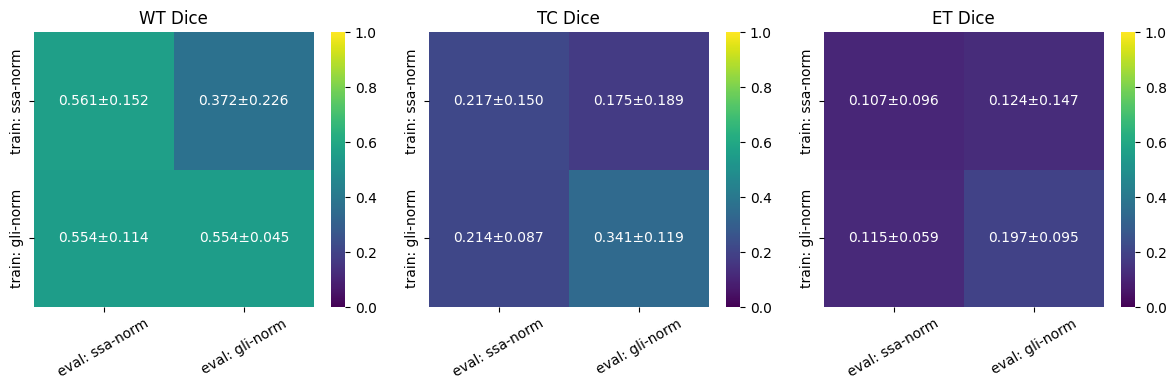

In [7]:
# 7b+) Plot mean±std heatmaps from the multiseed CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

multi_csv = REMOTE_RUNS_DIR / 'ped_only_cross_norm_multiseed.csv'
if not multi_csv.exists():
    raise FileNotFoundError(f'Missing {multi_csv}. Run the multi-seed cell first.')

dfm = pd.read_csv(multi_csv)
g = dfm.groupby('train_tag')[['dice_wt','dice_tc','dice_et']].agg(['mean','std'])
display(g)

# Order to form a 2x2 matrix: train {ssa,gli} x eval {ssa,gli}
order = ['ssa_train__ssa_eval', 'ssa_train__gli_eval', 'gli_train__ssa_eval', 'gli_train__gli_eval']
def _grid(metric):
    vals = []
    stds = []
    for tag in order:
        vals.append(float(g.loc[tag,(metric,'mean')]))
        stds.append(float(g.loc[tag,(metric,'std')]))
    M = np.array(vals).reshape(2,2)
    S = np.array(stds).reshape(2,2)
    return M, S

labels_x = ['eval: ssa-norm', 'eval: gli-norm']
labels_y = ['train: ssa-norm', 'train: gli-norm']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric, title in zip(axes, ['dice_wt','dice_tc','dice_et'], ['WT Dice','TC Dice','ET Dice']):
    M, S = _grid(metric)
    annot = np.vectorize(lambda m, s: f'{m:.3f}±{s:.3f}')(M, S)
    sns.heatmap(M, annot=annot, fmt='', vmin=0, vmax=1, cmap='viridis', xticklabels=labels_x, yticklabels=labels_y, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# 6c) (Optional) Mine ET-positive patches for a clearer ET ablation
ET (enhancing tumor) voxels are often rare. This step creates two extra patch folders containing only patches with ET present (`mask == 4`).
This makes the ET Dice heatmap much more informative when you only train on a small pilot subset.

In [5]:
# 6c) Mine ET-positive patches into separate folders
import shutil
from pathlib import Path
import numpy as np
import os

MIN_ET_VOX = int(os.environ.get('PED_MIN_ET_VOX', '10'))
ET_LABEL = 4

PED_PATCH_DIR_SSA_NORM_ET = REMOTE_REPO_ROOT / 'archive' / 'pediatric_patches_ssa_norm_et'
PED_PATCH_DIR_GLI_NORM_ET = REMOTE_REPO_ROOT / 'archive' / 'pediatric_patches_gli_norm_et'
PED_PATCH_DIR_SSA_NORM_ET.mkdir(parents=True, exist_ok=True)
PED_PATCH_DIR_GLI_NORM_ET.mkdir(parents=True, exist_ok=True)

def _mine_et(src_dir: Path, dst_dir: Path) -> int:
    kept = 0
    for f in sorted(Path(src_dir).glob('*.npz')):
        try:
            d = np.load(f)
            m = d['mask']
            et_vox = int(np.sum(m == ET_LABEL))
        except Exception:
            continue
        if et_vox >= MIN_ET_VOX:
            shutil.copy2(f, dst_dir / f.name)
            kept += 1
    return kept

ssa_kept = _mine_et(PED_PATCH_DIR_SSA_NORM, PED_PATCH_DIR_SSA_NORM_ET)
gli_kept = _mine_et(PED_PATCH_DIR_GLI_NORM, PED_PATCH_DIR_GLI_NORM_ET)

print('MIN_ET_VOX:', MIN_ET_VOX)
print('ET kept (ssa norm):', ssa_kept, '->', PED_PATCH_DIR_SSA_NORM_ET)
print('ET kept (gli norm):', gli_kept, '->', PED_PATCH_DIR_GLI_NORM_ET)

# Convenience: if you want the demo to train on ET-positive patches, set these env vars and re-run the demo cell.
if ssa_kept > 0:
    os.environ['PED_DEMO_TRAIN_DIR_SSA'] = str(PED_PATCH_DIR_SSA_NORM_ET)
    os.environ['PED_DEMO_EVAL_DIR_SSA'] = str(PED_PATCH_DIR_SSA_NORM_ET)
if gli_kept > 0:
    os.environ['PED_DEMO_TRAIN_DIR_GLI'] = str(PED_PATCH_DIR_GLI_NORM_ET)
    os.environ['PED_DEMO_EVAL_DIR_GLI'] = str(PED_PATCH_DIR_GLI_NORM_ET)

print('PED_DEMO_TRAIN_DIR_SSA:', os.environ.get('PED_DEMO_TRAIN_DIR_SSA'))
print('PED_DEMO_TRAIN_DIR_GLI:', os.environ.get('PED_DEMO_TRAIN_DIR_GLI'))

MIN_ET_VOX: 10
ET kept (ssa norm): 56 -> /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm_et
ET kept (gli norm): 56 -> /root/BrainTumorDetector/archive/pediatric_patches_gli_norm_et
PED_DEMO_TRAIN_DIR_SSA: /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm_et
PED_DEMO_TRAIN_DIR_GLI: /root/BrainTumorDetector/archive/pediatric_patches_gli_norm_et


In [14]:
# 7a) Train two tiny models (SSA-norm vs GLI-norm) and cross-evaluate on both PED patch dirs
import importlib.util, sys, subprocess

def _ensure(pkg: str):
    if importlib.util.find_spec(pkg) is None:
        print(f'Installing missing package: {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        print(f'Installed: {pkg}')

_ensure('pandas')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

def _remap_mask_4_to_3(mask: np.ndarray) -> np.ndarray:
    m = mask.astype(np.int16, copy=True)
    m[m == 4] = 3
    return m

class NPZPatchDataset(Dataset):
    def __init__(self, patch_dir: Path, limit: int | None = None, seed: int = 0):
        patch_dir = Path(patch_dir)
        files = sorted(patch_dir.glob('*.npz'))
        if limit is not None:
            rng = np.random.default_rng(seed)
            idx = np.arange(len(files))
            rng.shuffle(idx)
            files = [files[i] for i in idx[:limit]]
        self.files = files
        if not self.files:
            raise RuntimeError(f'No .npz patches found in {patch_dir}')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        d = np.load(self.files[i])
        x = d['image'].astype(np.float32)  # (4,128,128,128)
        y = _remap_mask_4_to_3(d['mask'])  # (128,128,128) labels 0..3
        return torch.from_numpy(x), torch.from_numpy(y).long()

class Tiny3DSeg(nn.Module):
    def __init__(self, in_ch: int = 4, out_ch: int = 4, base: int = 16):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv3d(in_ch, base, 3, padding=1), nn.InstanceNorm3d(base), nn.LeakyReLU(0.1, inplace=True))
        self.enc2 = nn.Sequential(nn.Conv3d(base, base*2, 3, stride=2, padding=1), nn.InstanceNorm3d(base*2), nn.LeakyReLU(0.1, inplace=True))
        self.enc3 = nn.Sequential(nn.Conv3d(base*2, base*4, 3, stride=2, padding=1), nn.InstanceNorm3d(base*4), nn.LeakyReLU(0.1, inplace=True))
        self.dec2 = nn.Sequential(nn.ConvTranspose3d(base*4, base*2, 2, stride=2), nn.InstanceNorm3d(base*2), nn.LeakyReLU(0.1, inplace=True))
        self.dec1 = nn.Sequential(nn.ConvTranspose3d(base*2, base, 2, stride=2), nn.InstanceNorm3d(base), nn.LeakyReLU(0.1, inplace=True))
        self.head = nn.Conv3d(base, out_ch, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x = self.dec2(x3)
        x = self.dec1(x)
        return self.head(x)

@torch.no_grad()
def dice_scores_from_logits(logits: torch.Tensor, y: torch.Tensor) -> dict:
    pred = torch.argmax(logits, dim=1)
    y = y.to(pred.device)
    def dice(a, b):
        a = a.bool(); b = b.bool()
        inter = (a & b).sum().float()
        denom = a.sum().float() + b.sum().float()
        return float((2*inter + 1e-6) / (denom + 1e-6))
    wt_p = pred > 0
    wt_y = y > 0
    tc_p = (pred == 1) | (pred == 3)
    tc_y = (y == 1) | (y == 3)
    et_p = pred == 3
    et_y = y == 3
    return {'dice_WT': dice(wt_p, wt_y), 'dice_TC': dice(tc_p, tc_y), 'dice_ET': dice(et_p, et_y)}

def train_quick(model: nn.Module, patch_dir: Path, train_limit: int = 32, epochs: int = 2, batch_size: int = 1, lr: float = 1e-3, seed: int = 0):
    ds = NPZPatchDataset(patch_dir, limit=train_limit, seed=seed)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    for ep in range(1, epochs + 1):
        losses = []
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach().cpu()))
        print(f'epoch {ep}/{epochs} loss={np.mean(losses):.4f} (n={len(losses)})')
    return model

@torch.no_grad()
def eval_quick(model: nn.Module, patch_dir: Path, limit: int = 32):
    ds = NPZPatchDataset(patch_dir, limit=limit, seed=123)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
    model.eval()
    rows = []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        rows.append(dice_scores_from_logits(logits, y))
    out = {k: float(np.mean([r[k] for r in rows])) for k in rows[0].keys()}
    out['n'] = len(rows)
    return out

# ---- Run the PED-only cross-norm demo ----
TRAIN_LIMIT = int(os.environ.get('PED_DEMO_TRAIN_LIMIT', '32'))
EVAL_LIMIT  = int(os.environ.get('PED_DEMO_EVAL_LIMIT', '32'))
EPOCHS      = int(os.environ.get('PED_DEMO_EPOCHS', '2'))

TRAIN_DIR_SSA = Path(os.environ.get('PED_DEMO_TRAIN_DIR_SSA', str(PED_PATCH_DIR_SSA_NORM)))
TRAIN_DIR_GLI = Path(os.environ.get('PED_DEMO_TRAIN_DIR_GLI', str(PED_PATCH_DIR_GLI_NORM)))
EVAL_DIR_SSA  = Path(os.environ.get('PED_DEMO_EVAL_DIR_SSA', str(PED_PATCH_DIR_SSA_NORM)))
EVAL_DIR_GLI  = Path(os.environ.get('PED_DEMO_EVAL_DIR_GLI', str(PED_PATCH_DIR_GLI_NORM)))

print('TRAIN_LIMIT=', TRAIN_LIMIT, 'EVAL_LIMIT=', EVAL_LIMIT, 'EPOCHS=', EPOCHS)
print('TRAIN_DIR_SSA:', TRAIN_DIR_SSA)
print('TRAIN_DIR_GLI:', TRAIN_DIR_GLI)
print('EVAL_DIR_SSA :', EVAL_DIR_SSA)
print('EVAL_DIR_GLI :', EVAL_DIR_GLI)

m_ssa = Tiny3DSeg()
m_gli = Tiny3DSeg()

print('\nTraining model on SSA-norm train dir...')
m_ssa = train_quick(m_ssa, TRAIN_DIR_SSA, train_limit=TRAIN_LIMIT, epochs=EPOCHS, seed=1)

print('\nTraining model on GLI-norm train dir...')
m_gli = train_quick(m_gli, TRAIN_DIR_GLI, train_limit=TRAIN_LIMIT, epochs=EPOCHS, seed=2)

results = []
for model_name, model in [('PED_train_SSA_NORM', m_ssa), ('PED_train_GLI_NORM', m_gli)]:
    for ds_name, ds_dir in [('PED_SSA_NORM', EVAL_DIR_SSA), ('PED_GLI_NORM', EVAL_DIR_GLI)]:
        r = eval_quick(model, ds_dir, limit=EVAL_LIMIT)
        results.append({'model': model_name, 'patch_dir': ds_name, **r})
        print(model_name, '->', ds_name, r)

df_demo = pd.DataFrame(results)
display(df_demo)

out_csv = REMOTE_RUNS_DIR / 'ped_only_cross_norm_demo.csv'
df_demo.to_csv(out_csv, index=False)
print('Wrote:', out_csv)

DEVICE: cuda
TRAIN_LIMIT= 32 EVAL_LIMIT= 32 EPOCHS= 2
TRAIN_DIR_SSA: /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm_et
TRAIN_DIR_GLI: /root/BrainTumorDetector/archive/pediatric_patches_gli_norm_et
EVAL_DIR_SSA : /root/BrainTumorDetector/archive/pediatric_patches_ssa_norm_et
EVAL_DIR_GLI : /root/BrainTumorDetector/archive/pediatric_patches_gli_norm_et

Training model on SSA-norm train dir...
epoch 1/2 loss=1.4414 (n=20)
epoch 2/2 loss=1.1682 (n=20)

Training model on GLI-norm train dir...
epoch 1/2 loss=1.0085 (n=20)
epoch 2/2 loss=0.7895 (n=20)
PED_train_SSA_NORM -> PED_SSA_NORM {'dice_WT': 0.1330585189163685, 'dice_TC': 0.06335793938487769, 'dice_ET': 0.030307484880904668, 'n': 20}
PED_train_SSA_NORM -> PED_GLI_NORM {'dice_WT': 0.12276285514235497, 'dice_TC': 0.05119690448045731, 'dice_ET': 0.019486338470996678, 'n': 20}
PED_train_GLI_NORM -> PED_SSA_NORM {'dice_WT': 0.15875066594430637, 'dice_TC': 9.515213166000347e-11, 'dice_ET': 1.1943143909520087e-08, 'n': 20}
PED_tra

,model,patch_dir,dice_WT,dice_TC,dice_ET,n
0,PED_train_SSA_NORM,PED_SSA_NORM,0.133059,6.335794e-02,3.030748e-02,20
1,PED_train_SSA_NORM,PED_GLI_NORM,0.122763,5.119690e-02,1.948634e-02,20
2,PED_train_GLI_NORM,PED_SSA_NORM,0.158751,9.515213e-11,1.194314e-08,20
3,PED_train_GLI_NORM,PED_GLI_NORM,0.232314,9.515213e-11,1.194314e-08,20


Wrote: /root/BrainTumorDetector/SSA_Type/results/remote_ablation_runs/ped_only_cross_norm_demo.csv


In [ ]:
# 8) Run the model↔dataset ablation matrix on REMOTE GPU (requires repo code + checkpoints)
ABLATION_SCRIPT = REMOTE_REPO_ROOT / 'SSA_Type' / 'src' / 'ablation_patch_matrix.py'
if not ABLATION_SCRIPT.exists():
    print('Ablation script not found:', ABLATION_SCRIPT)
    print('This remote host currently has kernel access only (no repo code/checkpoints).')
    print('You can still run the PED-only demo in Cell 11 above.')
else:
    # Checkpoints (methodologies)
    MODELS = {
        # SSA methodology (use best, fallback to latest)
        'SSA': SSA_CKPT if SSA_CKPT.exists() else SSA_CKPT_LATEST,
        # Glioma methodology
        'GLI': GLI_CKPT,
    }

    # Datasets
    PATCH_DIRS = {
        'SSA': SSA_PATCH_DIR,
        'GLI': GLI_PATCH_DIR,
        # Pediatric exported two ways to demonstrate preprocessing sensitivity
        'PED_SSA_NORM': PED_PATCH_DIR_SSA_NORM,
        'PED_GLI_NORM': PED_PATCH_DIR_GLI_NORM,
    }

    LIMIT = int(os.environ.get('LIMIT', '50'))  # start small (5/50), then scale
    ALLOW_PARTIAL = True
    COMPUTE_HD95 = False  # keep False unless LIMIT is tiny (HD95 is slower)

    for name, path in MODELS.items():
        print('MODEL', name, '->', path, 'exists=', Path(path).exists())
    for name, path in PATCH_DIRS.items():
        p = Path(path)
        n = len(list(p.glob('*.npz'))) if p.exists() else 0
        print('PATCH', name, '->', p, 'npz=', n)

    cmd = [sys.executable, str(ABLATION_SCRIPT)]
    for name, path in MODELS.items():
        cmd += ['--model', f'{name}={Path(path)}']
    for name, path in PATCH_DIRS.items():
        cmd += ['--patch-dir', f'{name}={Path(path)}']
    cmd += ['--limit', str(LIMIT)]
    if ALLOW_PARTIAL:
        cmd += ['--allow-partial']
    if COMPUTE_HD95:
        cmd += ['--compute-hd95']

    print('\nRunning:')
    print(' '.join(str(x) for x in cmd))
    proc = subprocess.run(cmd, cwd=str(REMOTE_REPO_ROOT))
    print('Exit code:', proc.returncode)
    if proc.returncode != 0:
        raise RuntimeError('Ablation script failed (see logs above).')

No ablation_patch_matrix CSV found; loading PED-only demo: /root/BrainTumorDetector/SSA_Type/results/remote_ablation_runs/ped_only_cross_norm_demo.csv


,model,patch_dir,dice_WT,dice_TC,dice_ET,n
0,PED_train_SSA_NORM,PED_SSA_NORM,0.133059,6.335794e-02,3.030748e-02,20
1,PED_train_SSA_NORM,PED_GLI_NORM,0.122763,5.119690e-02,1.948634e-02,20
2,PED_train_GLI_NORM,PED_SSA_NORM,0.158751,9.515213e-11,1.194314e-08,20
3,PED_train_GLI_NORM,PED_GLI_NORM,0.232314,9.515213e-11,1.194314e-08,20


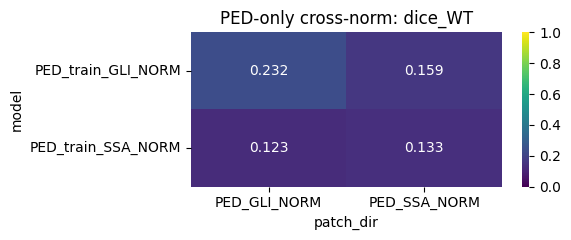

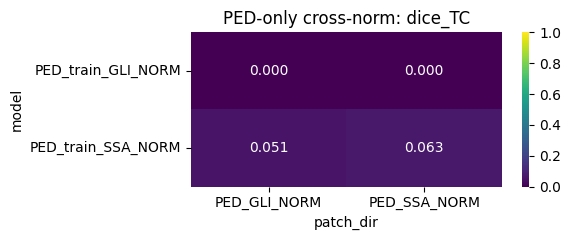

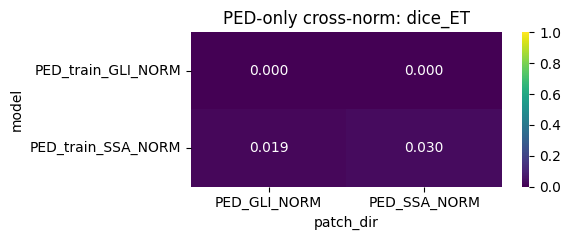

In [15]:
# 9) Load latest CSV + quick plots (runs on REMOTE)
import importlib.util, sys, subprocess

def _ensure(pkg: str):
    if importlib.util.find_spec(pkg) is None:
        print(f'Installing missing package: {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        print(f'Installed: {pkg}')

_ensure('pandas')
_ensure('matplotlib')
_ensure('seaborn')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

results_dir = REMOTE_REPO_ROOT / 'SSA_Type' / 'results'
csvs = sorted(results_dir.glob('ablation_patch_matrix_*.csv'))
demo_csv = REMOTE_RUNS_DIR / 'ped_only_cross_norm_demo.csv'

if csvs:
    latest_csv = csvs[-1]
    print('Latest ablation CSV:', latest_csv)
    df = pd.read_csv(latest_csv)
    df_ok = df[df['status'].isin(['ok', 'partial_load_ok'])].copy()
    display(df_ok.sort_values(['model', 'patch_dir']))

    if 'dice_ET' in df_ok.columns and not df_ok.empty:
        pivot = df_ok.pivot_table(index='model', columns='patch_dir', values='dice_ET', aggfunc='mean')
        plt.figure(figsize=(10, 3))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1)
        plt.title('ET Dice: Train(checkpoint) → Test(patch-dir)')
        plt.tight_layout()
        plt.show()
    else:
        print('No rows to plot, or dice_ET missing. Check df_ok/status columns.')
elif demo_csv.exists():
    print('No ablation_patch_matrix CSV found; loading PED-only demo:', demo_csv)
    df_demo = pd.read_csv(demo_csv)
    display(df_demo)
    for metric in ['dice_WT', 'dice_TC', 'dice_ET']:
        if metric in df_demo.columns:
            pivot = df_demo.pivot_table(index='model', columns='patch_dir', values=metric, aggfunc='mean')
            plt.figure(figsize=(6, 2.5))
            sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1)
            plt.title(f'PED-only cross-norm: {metric}')
            plt.tight_layout()
            plt.show()
else:
    raise FileNotFoundError(f'No ablation CSV in {results_dir} and no demo CSV at {demo_csv}.')